# Exploratory Data Analysis

**Project:** Medical Insurance Cost Prediction  
**Phase:** Day 18 - Exploratory Data Analysis  
**Dataset:** Cleaned & preprocessed data from Phase 3  
**Target Variable:** `charges`

This notebook explores the relationships between features and the target variable. No model training is performed here.

## Load Data

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproduce preprocessing from Phase 3
df_raw = pd.read_csv('../data/insurance.csv')
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

# Keep a copy with original categorical labels for visualisation
df_viz = df_raw.copy()

# Fully encoded version for correlation
df = pd.get_dummies(df_raw, columns=['sex', 'smoker', 'region'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Cleaned dataset shape:', df.shape)
print('Visualisation copy shape:', df_viz.shape)

Cleaned dataset shape: (1337, 9)
Visualisation copy shape: (1337, 7)


## Statistical Summary

In [2]:
df_viz.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
print('smoker value counts:')
print(df_viz['smoker'].value_counts())
print()
print('region value counts:')
print(df_viz['region'].value_counts())

smoker value counts:
smoker
no     1063
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## Age vs Charges

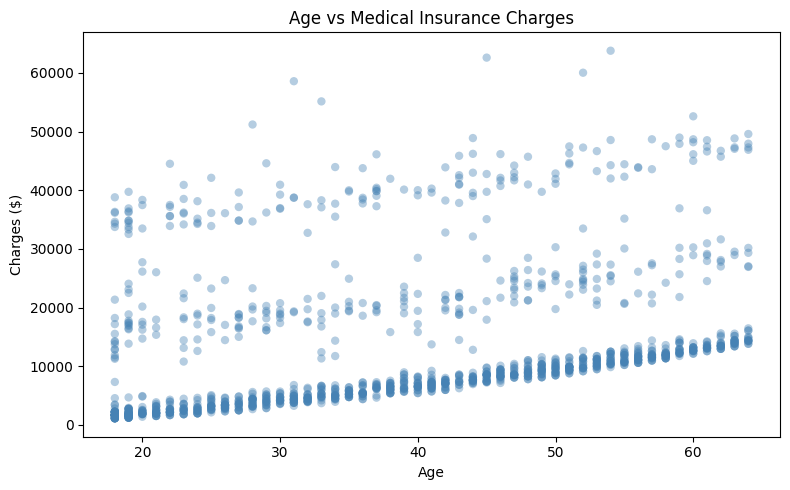

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_viz['age'], df_viz['charges'], alpha=0.4, color='steelblue', edgecolors='none')
ax.set_xlabel('Age')
ax.set_ylabel('Charges ($)')
ax.set_title('Age vs Medical Insurance Charges')
plt.tight_layout()
plt.show()

## BMI vs Charges

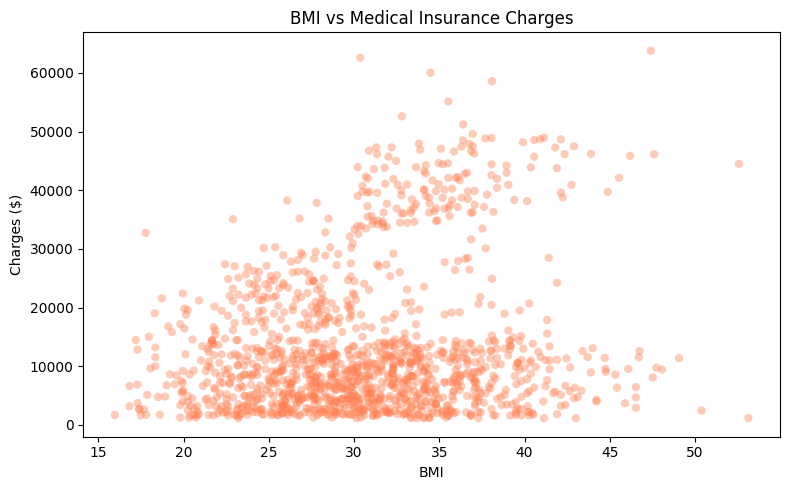

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_viz['bmi'], df_viz['charges'], alpha=0.4, color='coral', edgecolors='none')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges ($)')
ax.set_title('BMI vs Medical Insurance Charges')
plt.tight_layout()
plt.show()

## Smoking Status vs Charges

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10004\767919272.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(smoker_groups, labels=['Non-smoker', 'Smoker'], patch_artist=True)


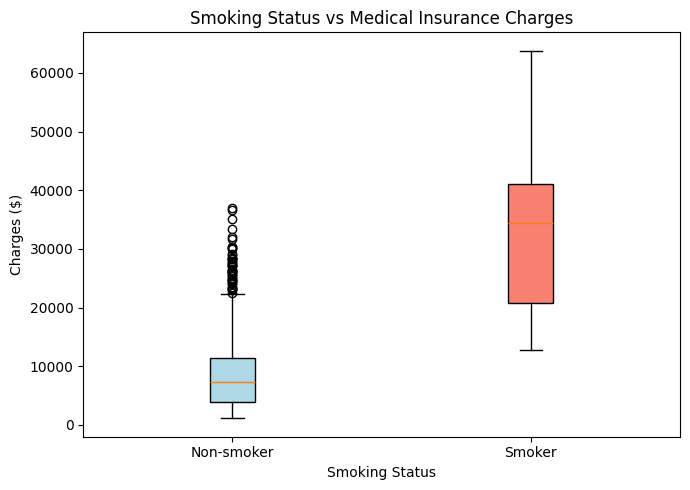

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
smoker_groups = [df_viz[df_viz['smoker'] == s]['charges'].values for s in ['no', 'yes']]
bp = ax.boxplot(smoker_groups, labels=['Non-smoker', 'Smoker'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_xlabel('Smoking Status')
ax.set_ylabel('Charges ($)')
ax.set_title('Smoking Status vs Medical Insurance Charges')
plt.tight_layout()
plt.show()

## Distribution of Charges

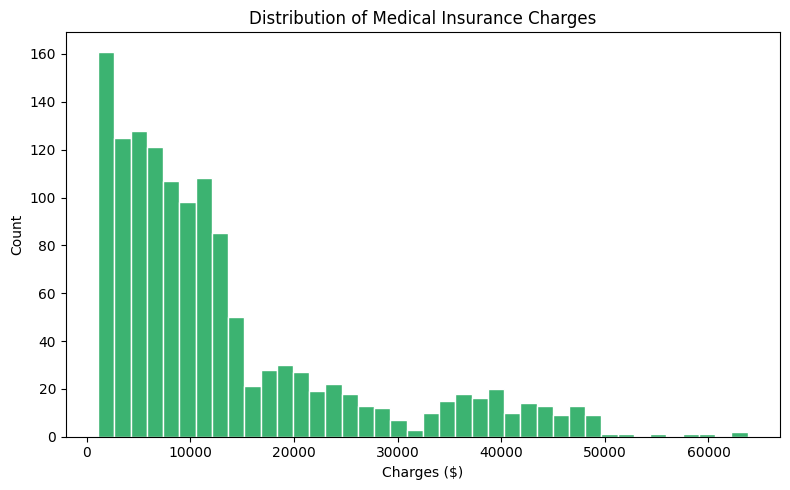

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_viz['charges'], bins=40, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Charges ($)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Medical Insurance Charges')
plt.tight_layout()
plt.show()

## Correlation Analysis

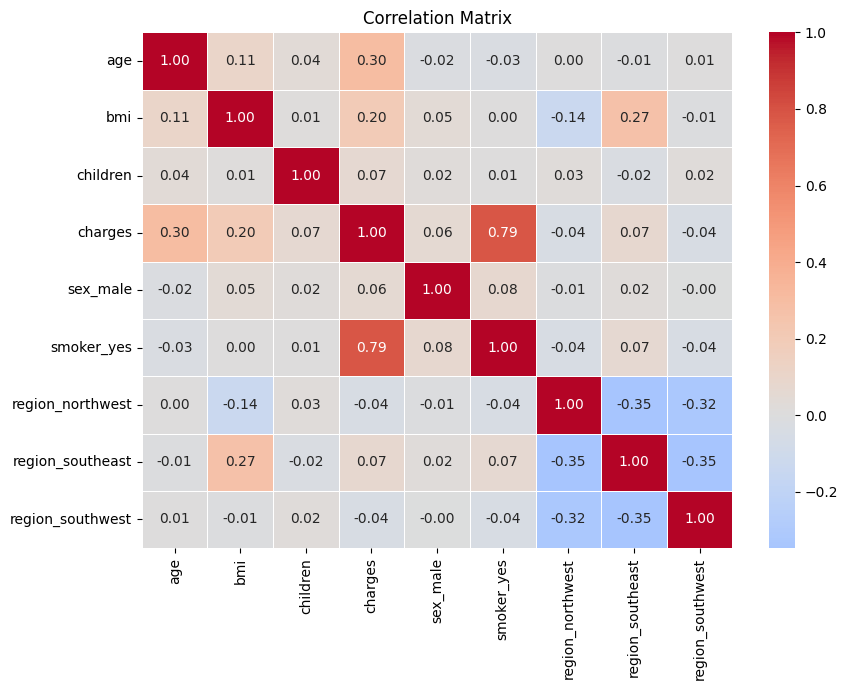

In [8]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
print('Correlation with charges (sorted):')
print(corr['charges'].sort_values(ascending=False).round(3))

Correlation with charges (sorted):
charges             1.000
smoker_yes          0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
sex_male            0.058
region_northwest   -0.039
region_southwest   -0.044
Name: charges, dtype: float64


In [ ]:
## Important Observations

Based on the actual charts and correlation results above:

1. **Smoking status is the strongest predictor** of insurance charges.  
   Correlation with charges: **0.79**.  
   The boxplot shows a dramatic difference — smokers pay substantially higher charges than non-smokers.

2. **Age has a moderate positive relationship** with charges.  
   Correlation: **0.30**.  
   The scatter plot shows a clear upward trend — older individuals tend to have higher charges, with visible banding patterns likely linked to smoking status.

3. **BMI has a weaker positive relationship** with charges.  
   Correlation: **0.20**.  
   The scatter plot shows that most low-BMI individuals have lower charges, but there is a cluster of high-BMI individuals with very high charges — likely smokers.

4. **Region, sex, and children have very small relationships** with charges.  
   None exceed a correlation of 0.08 — these may contribute marginally.

5. **The distribution of charges is right-skewed**, with most charges concentrated in the lower range and a tail of high-cost individuals — consistent with a minority of smokers driving costs up.

## Features That May Be Important

Based on the EDA, the features most likely to be useful for predicting `charges` are:

| Feature | Correlation with `charges` | Expected Importance |
|---|---|---|
| `smoker_yes` | 0.79 | **Very high** |
| `age` | 0.30 | Moderate |
| `bmi` | 0.20 | Moderate |
| `children` | 0.07 | Low |
| `sex_male` | 0.06 | Low |
| `region_*` | < 0.08 | Low |

Smoking status is expected to dominate the model. Age and BMI may provide useful signal. Region and sex are likely to contribute less.